In [97]:
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt
import backbone as bb
from tqdm import tqdm

#import train_labels dataset
cwd = os.getcwd()
filepath = 'data/train_labels.csv'
df = pd.read_csv(os.path.join(cwd, filepath))

#import train labels dataset using backbone module
file_path_trainlabels, file_path_trainimages, train_labels = bb.init_data()

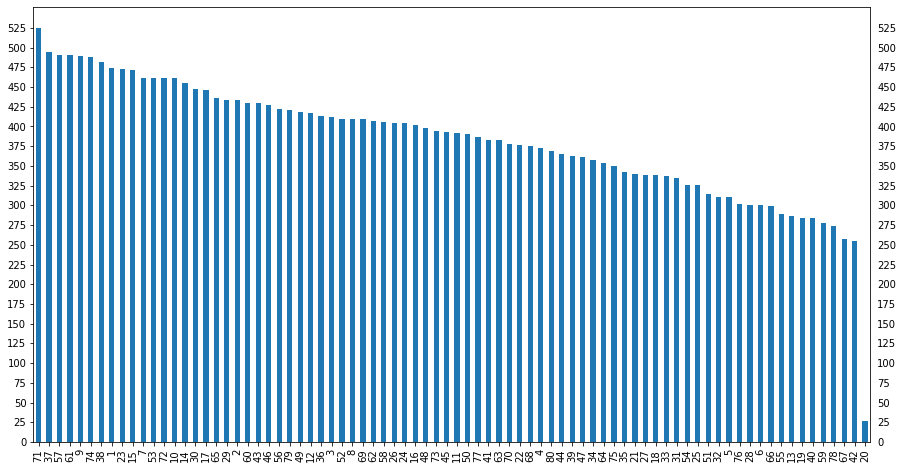

In [98]:
#Check label frequency
train_labels['label'] = train_labels['label'].astype('str')
labels = train_labels['label'].value_counts()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.tick_params(labelright=True)
labels.plot(kind='bar', figsize=(15,8), yticks=np.arange(0, max(labels)+1, 25))

# Splitting the Data and Data Augmentation

In [117]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

HEIGHT = 240
WIDTH = 240
IMG_SIZE = 240
#Data augmentation for the training set:
train_datagen = ImageDataGenerator(validation_split=0.2,
                                       rotation_range=2, 
                                       horizontal_flip=True,
                                       zoom_range=.1)

#Pre-processing the validation set (without data augmentation):
val_datagen = ImageDataGenerator(validation_split=0.2)

#Initiate a generator for the test set
test_datagen = ImageDataGenerator()

In [118]:
#Train dataset generator
train_generator=train_datagen.flow_from_dataframe(dataframe=train_labels, #dataframe with the image names and labels
                                            directory=file_path_trainimages, #filepath images
                                            x_col='img_name',
                                            y_col='label',
                                            subset='training',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42, #how the data is randomized
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest', #interpolation method for resizing images
                                            target_size=(HEIGHT, WIDTH))

Found 24490 validated image filenames belonging to 80 classes.


In [119]:
#Validation dataset generator
val_generator=val_datagen.flow_from_dataframe(dataframe=train_labels,
                                            directory=file_path_trainimages,
                                            x_col='img_name',
                                            y_col='label',
                                            subset='validation',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest',
                                            target_size=(HEIGHT, WIDTH))

Found 6122 validated image filenames belonging to 80 classes.


In [120]:
file_path_testimages, file_path_testlabels, test_labels = bb.get_test_paths()

#Test dataset generator
test_generator=test_datagen.flow_from_dataframe(dataframe=test_labels,
                                            directory=file_path_testimages,
                                            x_col='img_name',
                                            y_col='label',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=False,
                                            class_mode=None,
                                            class_names=None,
                                            interpolation='nearest',
                                            target_size=(HEIGHT, WIDTH))

Found 7653 validated image filenames.


In [121]:
#Check shapes of batches for both x and y. 
#Format x: (batch size, height, width, channels)
#Format y: (batch size, number of possible labels (one-hot encoded))
print(f'shape of batch in x_train: {train_generator.next()[0].shape}')
print(f'shape of batch in y_train: {train_generator.next()[1].shape}')

shape of batch in x_train: (32, 240, 240, 3)
shape of batch in y_train: (32, 80)


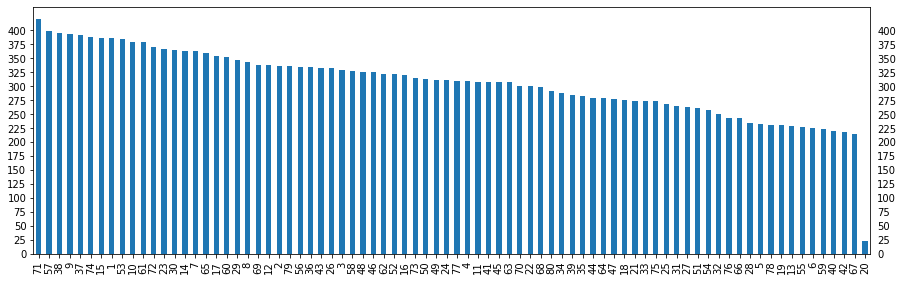

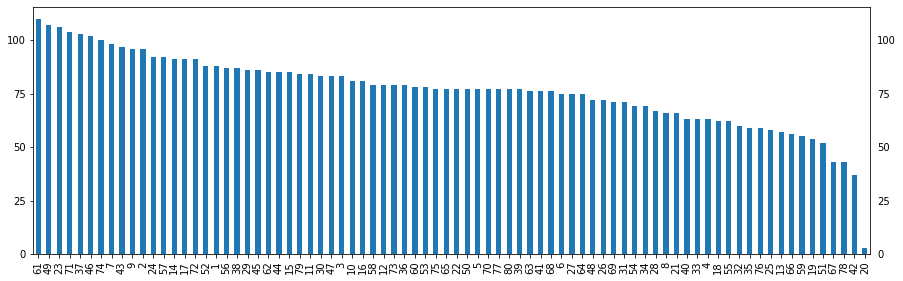

In [122]:
#Check that the training and validation split has split the data proportionally by label
dict_t = {str(v) : str(k) for k, v in train_generator.class_indices.items()}
dict_v = {str(v) : str(k) for k, v in val_generator.class_indices.items()}

clss = pd.Series(train_generator.classes).astype('str')
clss = clss.replace(dict_t)
clss = clss.value_counts()

fig = plt.figure()
ax = fig.add_subplot(211)
ax.tick_params(labelright=True)
clss.plot(kind='bar', figsize=(15,10), yticks=np.arange(0, max(clss)+1, 25))

clss2 = pd.Series(val_generator.classes).astype('str')
clss2 = clss2.replace(dict_v)
clss2 = clss2.value_counts()

fig = plt.figure()
ax = fig.add_subplot(212)
ax.tick_params(labelright=True)
clss2.plot(kind='bar', figsize=(15,10), yticks=np.arange(0, max(clss2)+1, 25))

# Balancing the Dataset

## 2 approaches: setting weights to labels and over-sampling in a balanced way

In [123]:
#Balancing dataset by setting weights to the labels
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
           'balanced',
            np.unique(train_generator.classes), 
            train_generator.classes)

#then use:    model.fit_generator(train_generator, class_weight=class_weights)

In [124]:
#Dataframe created with the labels and the weights given (just to check)
weights_df = pd.DataFrame()
weights_df['label'] = dict_t.values()
weights_df['weights'] = class_weights
print(f'Max weight (minority class): {weights_df[weights_df["label"] == "20"].values} label, weight')
print(f'Min weight (majority class): {weights_df[weights_df["label"] == "71"].values} label, weight')

Max weight (minority class): [['20' 12.755208333333334]] label, weight
Min weight (majority class): [['71' 0.7271377672209026]] label, weight


### Fitting EfficientNetB1

In [125]:
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
import tensorflow as tf

In [126]:
img_augmentation = Sequential(
    [
        preprocessing.RandomRotation(factor=0.15),
        preprocessing.RandomTranslation(height_factor=0.1, width_factor=0.1),
        preprocessing.RandomFlip(),
        preprocessing.RandomContrast(factor=0.1),
    ],
    name="img_augmentation",
)

In [127]:
from tensorflow.keras.layers.experimental import preprocessing
def build_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = img_augmentation(inputs)
    model = EfficientNetB1(include_top=False, input_tensor=x, weights="imagenet")

    # Freeze the pretrained weights
    model.trainable = False

    # Rebuild top
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(80, activation="softmax", name="pred")(x)

    # make decay in optimizer
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1.5e-2,
    decay_steps=10000,
    decay_rate=0.9)

    # Compile
    model = tf.keras.Model(inputs, outputs, name="EfficientNet")
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

In [128]:
NUM_CLASSES = np.unique(train_generator.classes)
epochs = 8  

In [132]:
import matplotlib.pyplot as plt


def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()

In [129]:
model = build_model(num_classes=NUM_CLASSES[0])
model.summary()

Model: "EfficientNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_14 (InputLayer)           [(None, 240, 240, 3) 0                                            
__________________________________________________________________________________________________
img_augmentation (Sequential)   (None, 240, 240, 3)  0           input_14[0][0]                   
__________________________________________________________________________________________________
rescaling_10 (Rescaling)        (None, 240, 240, 3)  0           img_augmentation[0][0]           
__________________________________________________________________________________________________
normalization_10 (Normalization (None, 240, 240, 3)  7           rescaling_10[0][0]               
_______________________________________________________________________________________

In [130]:
hist = model.fit(train_generator, epochs=epochs, validation_data=val_generator, verbose=1)
plot_hist(hist)

Epoch 1/8
766/766 - 1991s - loss: 3.5781 - accuracy: 0.2848 - val_loss: 2.3605 - val_accuracy: 0.4165
Epoch 2/8
766/766 - 1937s - loss: 2.7727 - accuracy: 0.3430 - val_loss: 2.3957 - val_accuracy: 0.4255
Epoch 3/8
766/766 - 1931s - loss: 2.8171 - accuracy: 0.3401 - val_loss: 2.4397 - val_accuracy: 0.4245
Epoch 4/8
766/766 - 1934s - loss: 2.8953 - accuracy: 0.3323 - val_loss: 2.5937 - val_accuracy: 0.4023
Epoch 5/8
766/766 - 1940s - loss: 2.9254 - accuracy: 0.3323 - val_loss: 2.4669 - val_accuracy: 0.4303
Epoch 6/8
766/766 - 1927s - loss: 2.9388 - accuracy: 0.3331 - val_loss: 2.4448 - val_accuracy: 0.4316
Epoch 7/8
766/766 - 1930s - loss: 2.9600 - accuracy: 0.3363 - val_loss: 2.5313 - val_accuracy: 0.4129
Epoch 8/8
766/766 - 1927s - loss: 2.9659 - accuracy: 0.3362 - val_loss: 2.6146 - val_accuracy: 0.4080


NameError: name 'plot_hist' is not defined

In [131]:
def unfreeze_model(model):
    # We unfreeze the top 20 layers while leaving BatchNorm layers frozen
    for layer in model.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )


unfreeze_model(model)
model.summary()

Model: "EfficientNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_14 (InputLayer)           [(None, 240, 240, 3) 0                                            
__________________________________________________________________________________________________
img_augmentation (Sequential)   (None, 240, 240, 3)  0           input_14[0][0]                   
__________________________________________________________________________________________________
rescaling_10 (Rescaling)        (None, 240, 240, 3)  0           img_augmentation[0][0]           
__________________________________________________________________________________________________
normalization_10 (Normalization (None, 240, 240, 3)  7           rescaling_10[0][0]               
_______________________________________________________________________________________

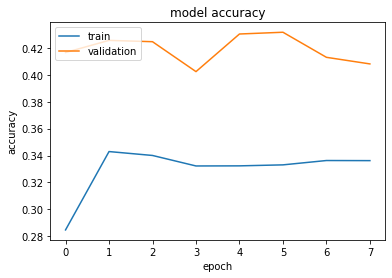

In [133]:
plot_hist(hist)

In [134]:
epochs = 8  # @param {type: "slider", min:8, max:50}
hist = model.fit(train_generator, epochs=epochs, validation_data=val_generator, verbose=1)
plot_hist(hist)

Epoch 1/8
766/766 [==============================] - 2304s 3s/step - loss: 2.3619 - accuracy: 0.4241 - val_loss: 2.0152 - val_accuracy: 0.5222
Epoch 2/8
533/766 [===================>..........] - ETA: 21:00 - loss: 2.1365 - accuracy: 0.4639

KeyboardInterrupt: 

In [ ]:
pickle.dump(hist, open('efficientnetB0.sav', 'wb'))

### Note that the following approach (over-sampling) does not work yet

Balancing dataset by over-sampling (data has to be imported in a different way)
from imblearn.over_sampling import RandomOverSampler
from tensorflow import keras
from imblearn.tensorflow import balanced_batch_generator

def balancer(x, y, datagen, batch_size):
    datagen.fit(x)
    generator, steps_per_epoch = balanced_batch_generator(x, y, sampler=RandomOverSampler(),
                                                                   batch_size=batch_size, random_state=42)
    
    x_batch, y_batch = generator.next()
    return datagen.flow(x_batch, y_batch, batch_size=batch_size).next()

X_train = []
for label in tqdm(train_labels['img_name']):
    X_train.append(np.expand_dims(plt.imread(file_path_trainimages + label), axis=0))
d = {'images':X_train,'labels':train_labels['label']}
df = pd.DataFrame(d)

from keras.utils.data_utils import Sequence
from imblearn.over_sampling import RandomOverSampler
from imblearn.tensorflow import balanced_batch_generator

class BalancedDataGenerator(Sequence):
    """ImageDataGenerator + RandomOversampling"""
    def __init__(self, x, y, datagen, batch_size=32):
        self.datagen = datagen
        self.batch_size = min(batch_size, x.shape[0])
        datagen.fit(x)
        self.gen, self.steps_per_epoch = balanced_batch_generator(x.reshape(x.shape[0], -1), y, sampler=RandomOverSampler(), batch_size=self.batch_size, keep_sparse=True)
        self._shape = (self.steps_per_epoch * batch_size, *x.shape[1:])
        
    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        x_batch, y_batch = self.gen.__next__()
        x_batch = x_batch.reshape(-1, *self._shape[1:])
        return self.datagen.flow(x_batch, y_batch, batch_size=self.batch_size).next()

datagen = ImageDataGenerator()
balanced_train = BalancedDataGenerator(df['images'].values, str(df['labels'].values), datagen, 32)

img = plt.imread(os.path.join(cwd, 'data/train_set/train_set/train_1.jpg'))
img1 = np.expand_dims(img, axis=0)
np.expand_dims(df['images'].values[0], axis=0).shape
df['images'].values[0].shape